In [ ]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Binomial Distribution - MLE

n = 10
p = 0.5
x = 3

probability = binom.pmf(x,n,p)
print("Probability of exactly 3 succeses: ", probability)

Probability of exactly 3 succeses:  0.1171875


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


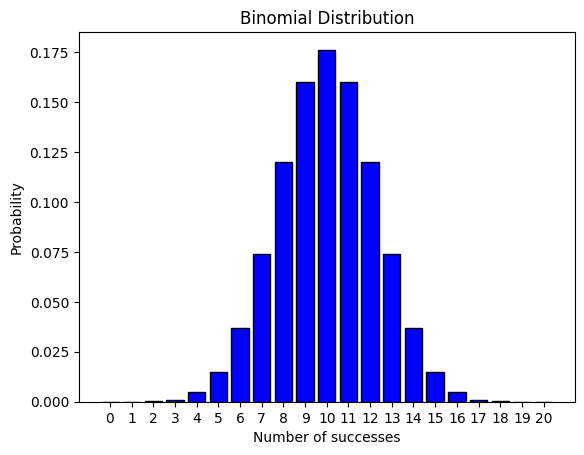

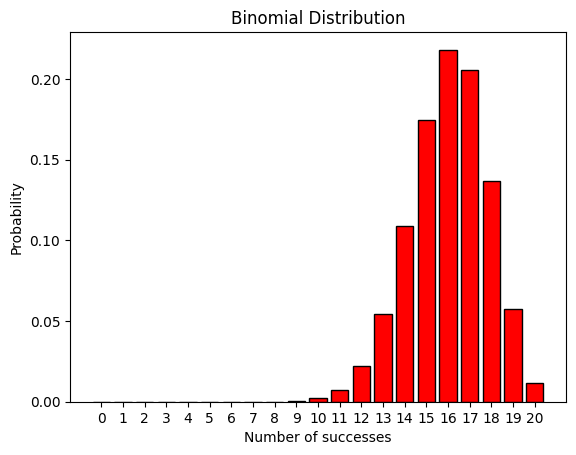

In [ ]:
# Visualizing how p affects the shape of binomial distribution when the number of trials n is fixed

n = 20
p1 = 0.5
x = np.arange(0, n+1)
pmf1 = binom.pmf(x, n, p1)
print(x)

plt.bar(x, pmf1, color='blue', edgecolor = 'black')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.title('Binomial Distribution')
plt.xticks(x)
plt.show()

p2 = 0.8
pmf2 = binom.pmf(x, n, p2)

plt.bar(x, pmf2, color='red', edgecolor = 'black')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.title('Binomial Distribution')
plt.xticks(x)
plt.show()

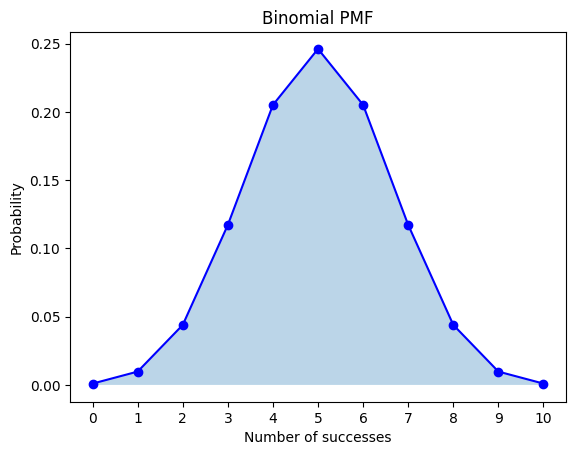

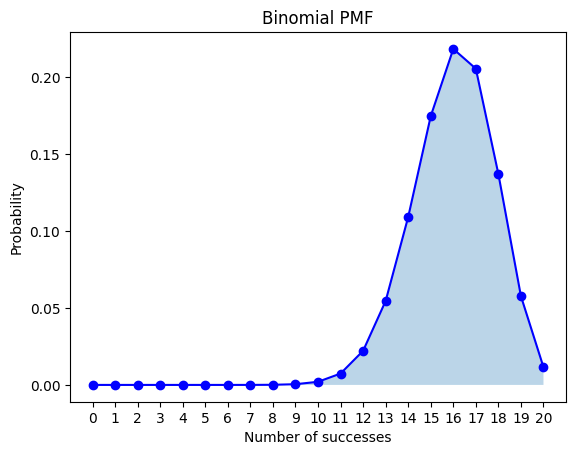

In [ ]:
p3 = 0.5
n3 = 10
x = np.arange(0, n3+1)
pmf3 = binom.pmf(x, n3, p3)

plt.plot(x, pmf3, marker='o', linestyle='-', color='blue')
plt.fill_between(x, pmf3, alpha=0.3)
plt.title('Binomial PMF')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.xticks(x)
plt.show()

p4 = 0.8
n4 = 20
x = np.arange(0, n4+1)
pmf3 = binom.pmf(x, n4, p4)

plt.plot(x, pmf3, marker='o', linestyle='-', color='blue')
plt.fill_between(x, pmf3, alpha=0.3)
plt.title('Binomial PMF')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.xticks(x)
plt.show()



In [ ]:
np.random.seed(42)
n = 10
p_true = 0.3
N = 1000

data = np.random.binomial(n, p_true, N)

# find sample mean and sample variance
sample_mean = np.mean(data)
sample_var = np.var(data, ddof=0)
print("Sample mean: ", sample_mean)
print("Sample variance: ", sample_var)

Sample mean:  2.935
Sample variance:  2.100775


In [ ]:
# General Formula
# pop mean = np
pop_mean = n*p_true
print("Population Mean ", pop_mean)

# variance = np(1-p)
pop_var = (pop_mean * (1-p_true))
print("Population Variance ", pop_var)

Population Mean  3.0
Population Variance  2.0999999999999996


In [ ]:
# Method of Moments estimate
p_mom = sample_mean / n

print("True p:", p_true)
print("MoM p-hat:", p_mom)

# Implied population moments
print("Implied Population mean:", n * p_mom)
print("Implied Population variance:", n * p_mom * (1 - p_mom))


True p: 0.3
MoM p-hat: 0.2935
Implied Population mean: 2.9349999999999996
Implied Population variance: 2.0735775


In [ ]:
# Using Maximum Likelihood Estimation (MLE)
p_mle = sample_mean / n
mu_mle = n * p_mle
var_mle = n * p_mle * (1 - p_mle)

print("True p:", p_true)
print("MLE p-hat:", p_mle)
print("Implied Population mean:", mu_mle)

True p: 0.3
MLE p-hat: 0.2935
Implied Population mean: 2.9349999999999996


In [ ]:
# CRBL
# gives min acheivable variance

n = 10
p = 0.3
N = 1000

# CRBL for p
crbl_p = (p * (1- p)) / (N * n)

# CRBL for mean
crbl_mu = (n * p * (1-p)) / N

print("CRBL for p: ", crbl_p)
print("CRBL for mu: ", crbl_mu)

CRBL for p:  2.1e-05
CRBL for mu:  0.0020999999999999994


In [ ]:
# Practical Application: Quality Control using Binomial Distribution
# n a fact produces item pro that item is defect = p inspect n items
# find pro of getting exactlt k defect items,
# at most k defect
# more than k defects (deision threshold)
# ===============================================


n = 20      # number of items inspected
p = 0.5    # probability an item is defective
k = 2       # defect threshold

# 1. Probability of exactly k defects
prob_exact_k = binom.pmf(k, n, p)

# 2. Probability of at most k defects (X <= k)
prob_at_most_k = binom.cdf(k, n, p)

# 3. Probability of more than k defects (X > k)
prob_more_than_k = 1 - prob_at_most_k

# Print results
print(f"P(X = {k}) = {prob_exact_k:.6f}")
print(f"P(X ≤ {k}) = {prob_at_most_k:.6f}")
print(f"P(X > {k}) = {prob_more_than_k:.6f}")


P(X = 2) = 0.000181
P(X ≤ 2) = 0.000201
P(X > 2) = 0.999799


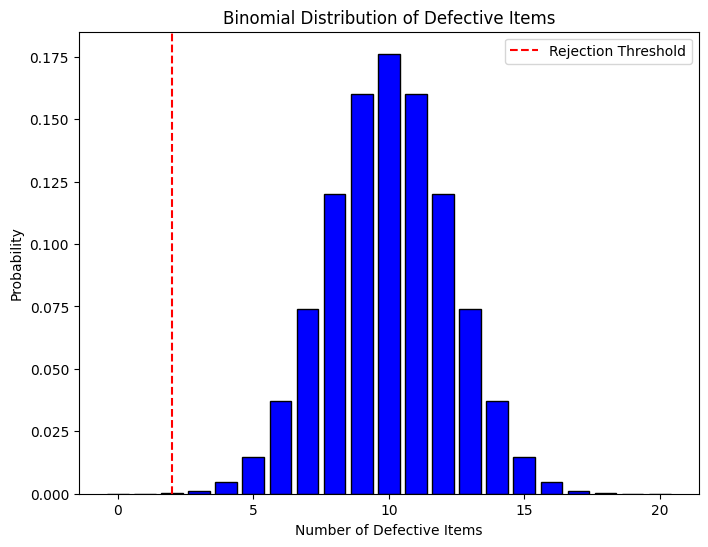

In [ ]:
x = np.arange(0, n + 1)
pmf = binom.pmf(x, n, p)

plt.figure(figsize=(8, 6))
plt.bar(x, pmf, color='blue', edgecolor='black')
plt.axvline(k, color='red', linestyle='--', label='Rejection Threshold')
plt.title(f'Binomial Distribution of Defective Items')
plt.xlabel('Number of Defective Items')
plt.ylabel('Probability')
plt.legend()

plt.show()